# APN Dataset EDA Report: USHCN

本报告用于深入理解该数据集在 APN 项目中的形态、含义与时序特性。

- 覆盖内容：数据来源、样本规模、不规则采样特性、缺失模式、变量相关性、典型时序轨迹
- 注意：首次运行可能触发自动下载或预处理（取决于数据集）


## 数据集背景

USHCN 是美国历史气候网络的站点级时间序列。
APN 当前路径采用 DeBrouwer2019 的稀疏化子集（5 通道，约 4 年窗口）。
任务是基于前段稀疏观测预测后续观测。


In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)
if (PROJECT_ROOT / 'reports').exists() and str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from reports.irregular_eda_utils import (
    compute_dataset_summary,
    get_sample_lengths,
    plot_channel_correlation,
    plot_channel_missingness,
    plot_interarrival_distribution,
    plot_multichannel_trajectories,
    plot_sample_length_distributions,
    to_long_frame,
)

sns.set_theme(style='whitegrid', context='talk')
np.random.seed(0)


/home/yixin/study/imts/APN


## 1) 加载数据并统一结构

将不同数据集统一为 records = [{t, x}] 形式：
- t: 一维时间戳数组
- x: 二维观测矩阵 [time, channel]


In [3]:
from data.dependencies.tsdm.tasks.ushcn_debrouwer2019 import USHCN_DeBrouwer2019
from reports.irregular_eda_utils import records_from_task_dataset

dataset_name = 'USHCN'
time_unit = 'normalized time (0-1)'

task = USHCN_DeBrouwer2019(seq_len=150 - 0.5, pred_len=3, value_norm='none')
all_ds = task.get_dataset((0, 'train'))
records = records_from_task_dataset(all_ds)
channel_names = [str(c) for c in task.dataset.columns.tolist()]
print(f'Loaded {len(records)} samples from fold-0 train split.')


/home/yixin/study/imts/APN/data/dependencies/tsdm/utils/remote.py:15: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:285: UserWarning: File 'USHCN_DeBrouwer2019.parquet' failed to validate!File hash '7c7fe25f08de4705320e6158cf2fb3eaa4697253dacc330ba0e94606167fee56' does not match reference 'bbd12ab38b4b7f9c69a07409c26967fe16af3b608daae9816312859199b5ce86'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.warn(
/home/yixin/study/imts/APN/data/dependencies/tsdm/datasets/base.py:285: UserWarning: File 'USHCN_DeBrouwer2019.parquet' failed to validate!File hash '7c7fe25f08de4705320e6158cf2fb3eaa4697253dacc330ba0e94606167fee56' does not match reference 'bbd12ab38b4b7f9c69a07409c26967fe16af3b608daae9816312859199b5ce86'.𝗜𝗴𝗻𝗼𝗿𝗲 𝘁𝗵𝗶𝘀 𝘄𝗮𝗿𝗻𝗶𝗻𝗴 𝗶𝗳 𝘁𝗵𝗲 𝗳𝗶𝗹𝗲 𝗳𝗼𝗿𝗺𝗮𝘁 𝗶𝘀 𝗽𝗮𝗿𝗾𝘂𝗲𝘁.
  warnings.w

Loaded 901 samples from fold-0 train split.


In [4]:
summary = compute_dataset_summary(records, channel_names)
lens = get_sample_lengths(records)
summary


n_samples              901.000000
n_channels               5.000000
mean_timestamps        237.624861
median_timestamps      245.000000
mean_observations      261.674806
median_observations    271.000000
mean_duration            0.742779
dtype: float64

## 2) 样本级统计

观察每个样本时间点数量、总观测数量、时长分布。

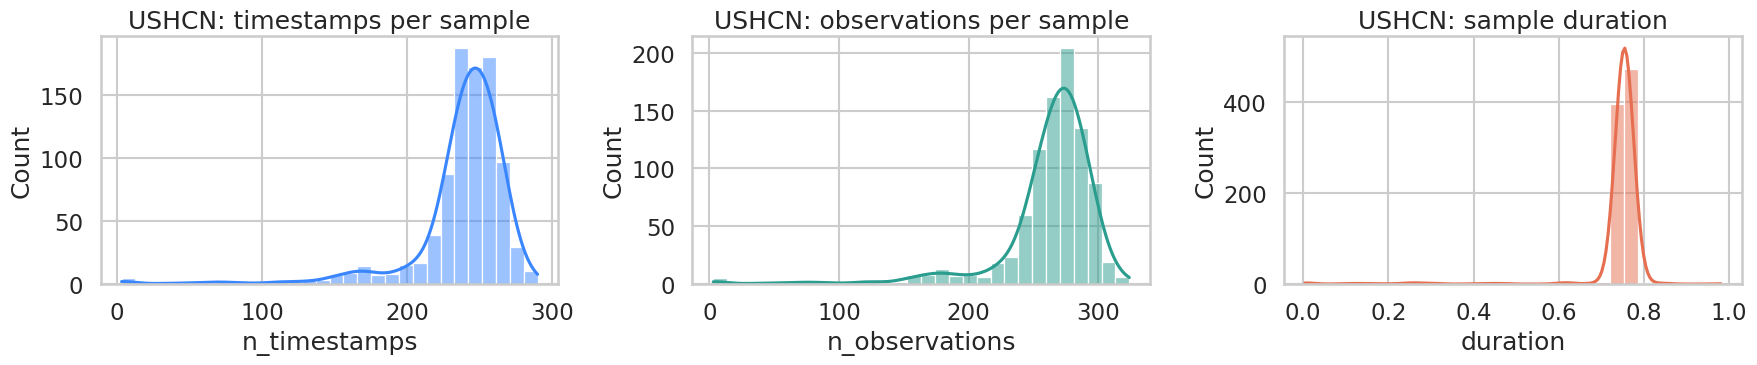

In [5]:
plot_sample_length_distributions(lens, title_prefix=f'{dataset_name}: ')

## 3) 生成长表并查看总体观测规模

In [6]:
long_df = to_long_frame(records, channel_names)
print('long_df shape:', long_df.shape)
long_df.head()


long_df shape: (235769, 4)


,sample_id,time,channel,value
0,0,0.002,Value_2,-0.173762
1,0,0.003,Value_3,0.128008
2,0,0.006,Value_2,-0.173762
3,0,0.006,Value_4,-0.480973
4,0,0.007,Value_0,-0.305700


## 4) 缺失与稀疏模式（样本 x 通道）

热图显示 log(1 + 观测次数)，越亮表示该通道在该样本中记录越密集。

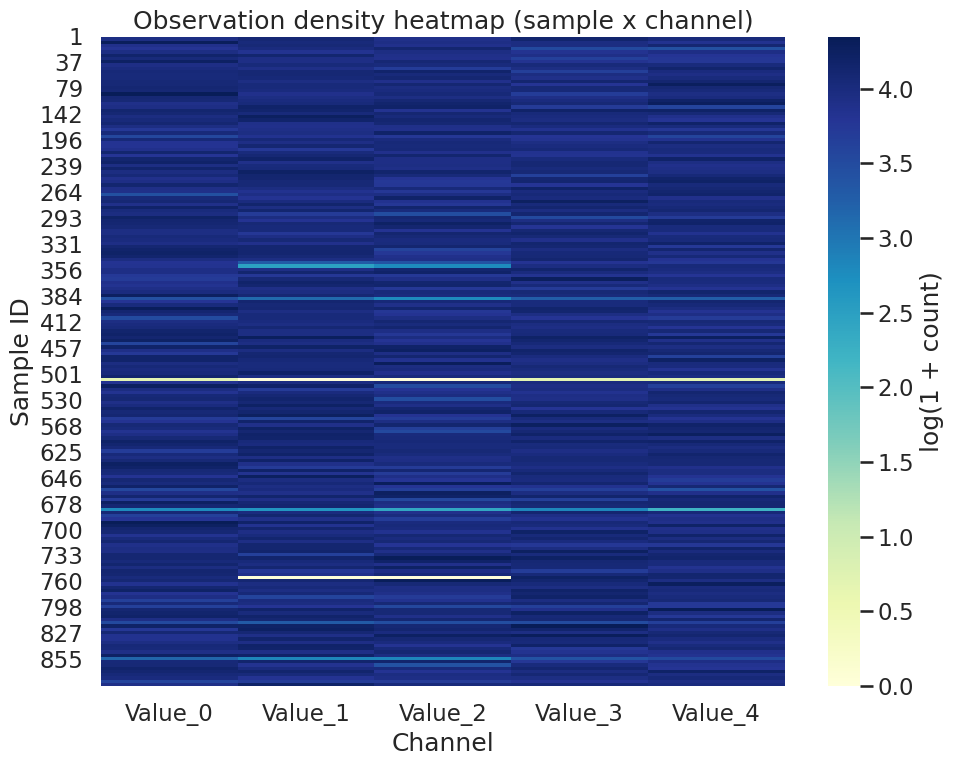

In [7]:
plot_channel_missingness(long_df, channel_names, n_samples=200)

## 5) 采样间隔分布

衡量不规则性：如果分布非常分散，说明采样时间并不均匀。

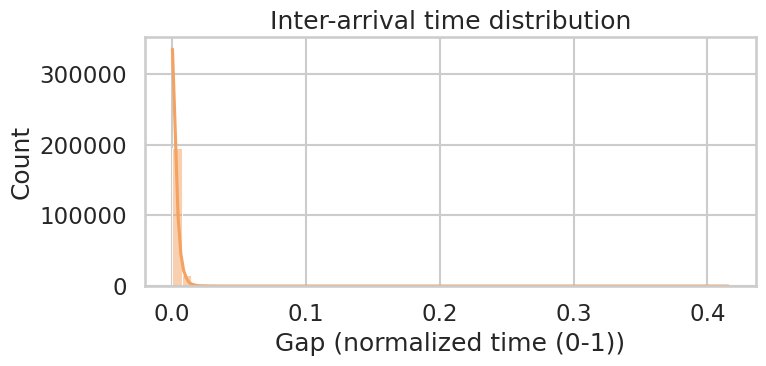

In [8]:
plot_interarrival_distribution(records, time_unit=time_unit)

## 6) 多变量时序轨迹（随机样本）

显示若干关键通道的多样本轨迹叠加。

In [9]:
channels_to_plot = channel_names[:4] if len(channel_names) >= 4 else channel_names
channels_to_plot


['Value_0', 'Value_1', 'Value_2', 'Value_3']

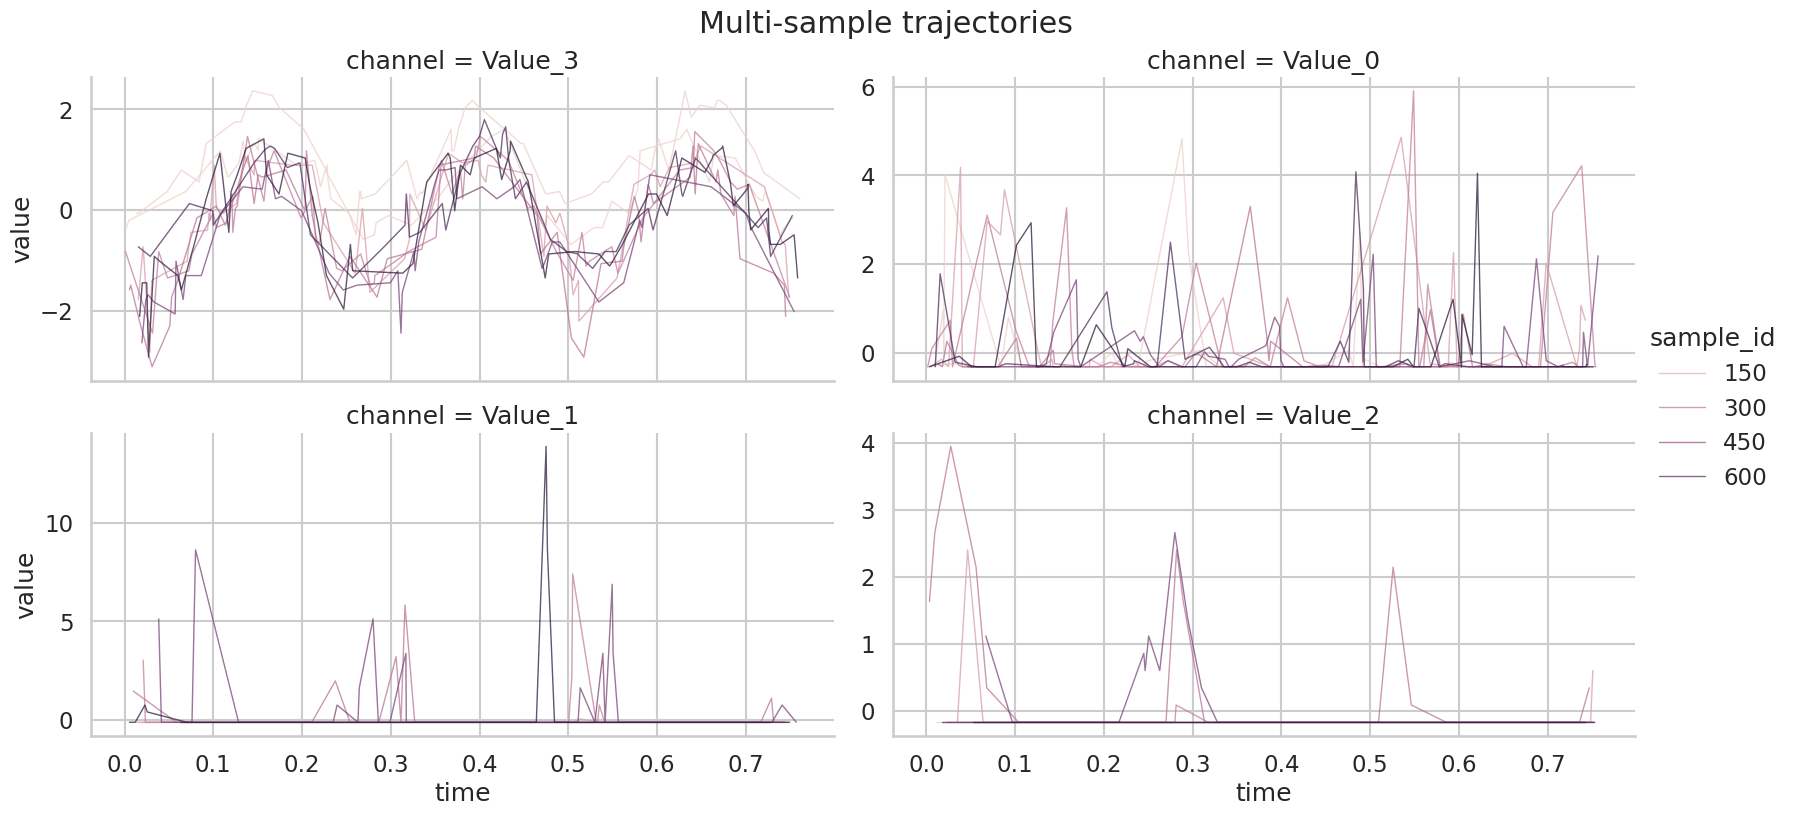

In [10]:
import importlib
import reports.irregular_eda_utils as _eda

# Force reload to pick up the latest function signature from disk.
_eda = importlib.reload(_eda)

try:
    _eda.plot_multichannel_trajectories(
        long_df,
        channels=channels_to_plot,
        n_samples=8,
        height=4.2,
        aspect=2.0,
    )
except TypeError:
    # Backward-compatible fallback if an older function object is still in memory.
    plt.figure(figsize=(16, 6))
    _eda.plot_multichannel_trajectories(
        long_df,
        channels=channels_to_plot,
        n_samples=8,
    )

## 7) 通道相关性

基于“每个样本每个通道的均值”估计变量之间的相关结构。

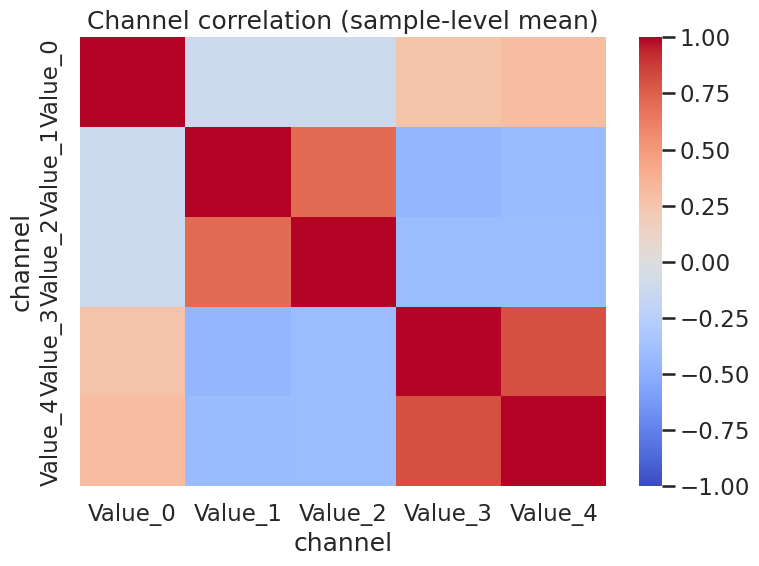

In [11]:
plot_channel_correlation(long_df, channel_names, max_samples=300)

## 8) 结论模板

你可以根据上面的图与统计，从以下角度总结：
1. 数据规模与稀疏程度：样本数、每样本观测数、时长分布
2. 不规则时间特征：时间间隔是否长尾、是否存在明显采样节律
3. 变量信息密度：哪些通道最稀疏、哪些最稳定
4. 变量联动关系：相关热图是否出现明显块状结构
5. 建模启发：是否适合 patch、插值、显式时间编码等策略
